# Ứng dụng 1 - Dự đoán tiểu đường

**Mục tiêu:** dự đoán một người tham gia khảo sát có thuộc nhóm mắc tiểu đường hay không từ 21 đặc trưng sức khỏe và lối sống.

## 1. Chuẩn bị môi trường và thư viện

Phần này khai báo các thư viện dùng để xử lý dữ liệu, trực quan hóa, tiền xử lý, huấn luyện, đánh giá và lưu mô hình.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import time
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)

BASE_DIR = Path(r"D:\Assignment2")
DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "models"

## 2. Đọc dữ liệu và xác định bài toán

Mỗi quan sát đại diện cho một người tham gia khảo sát BRFSS. Nhãn `Diabetes_binary` nhận giá trị `0` nếu không mắc tiểu đường và `1` nếu mắc tiểu đường.

In [2]:
DATA_PATH = (
    DATA_DIR
    / "diabetes"
    / "diabete.csv"
)
df = pd.read_csv(DATA_PATH)

print("Dataset path :", DATA_PATH)
print("Dataset shape:", df.shape)

display(df.head())

Dataset path : D:\Assignment2\data\diabetes\diabete.csv
Dataset shape: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
dataset_info = pd.DataFrame({
    "Item": [
        "Dataset",
        "Source",
        "Kaggle URL",
        "Rows",
        "Columns",
        "Input Features",
        "Target",
        "One observation"
    ],
    "Value": [
        "Diabetes Health Indicators Dataset",
        "Kaggle",
        "https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset",
        df.shape[0],
        df.shape[1],
        df.shape[1] - 1,
        "Diabetes_binary",
        "One BRFSS survey respondent"
    ]
})

display(dataset_info)

,Item,Value
0,Dataset,Diabetes Health Indicators Dataset
1,Source,Kaggle
2,Kaggle URL,https://www.kaggle.com/datasets/alexteboul/dia...
3,Rows,253680
4,Columns,22
5,Input Features,21
6,Target,Diabetes_binary
7,One observation,One BRFSS survey respondent


## 3. Khảo sát và tìm hiểu dữ liệu

Dữ liệu gốc được kiểm tra thông qua kích thước, tên cột, kiểu dữ liệu, một số bản ghi mẫu và thống kê mô tả trước khi biến đổi.

In [4]:
print("Number of rows   :", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

print("\nDataFrame info:")
df.info()

Number of rows   : 253680
Number of columns: 22

Columns:
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActiv

In [5]:
display(
    df.describe().T
)

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


## 4. Đánh giá chất lượng dữ liệu

Phần này kiểm tra giá trị thiếu, dòng trùng lặp, mức độ mất cân bằng của nhãn, miền giá trị hợp lệ và các quan sát đáng chú ý.

In [6]:
print("===== MISSING VALUES =====")

missing_table = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percent": df.isna().mean() * 100
})

display(missing_table)

print(
    "Total missing:",
    df.isna().sum().sum()
)


print("\n===== DUPLICATES =====")

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

print(
    "Duplicate percentage:",
    round(
        duplicate_count / len(df) * 100,
        2
    ),
    "%"
)


print("\n===== TARGET DISTRIBUTION =====")

target_table = pd.DataFrame({
    "Count":
        df["Diabetes_binary"]
        .value_counts()
        .sort_index(),

    "Percent":
        df["Diabetes_binary"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
})

display(
    target_table.round(2)
)

===== MISSING VALUES =====


,Missing_Count,Missing_Percent
Diabetes_binary,0,0.0
HighBP,0,0.0
HighChol,0,0.0
CholCheck,0,0.0
BMI,0,0.0
Smoker,0,0.0
Stroke,0,0.0
HeartDiseaseorAttack,0,0.0
PhysActivity,0,0.0
Fruits,0,0.0


Total missing: 0

===== DUPLICATES =====
Duplicate rows: 24206
Duplicate percentage: 9.54 %

===== TARGET DISTRIBUTION =====


,Count,Percent
Diabetes_binary,,
0.0,218334,86.07
1.0,35346,13.93


## 5. Xác định và kiểm tra đặc trưng

Các đặc trưng được chia thành nhóm nhị phân, thứ bậc, số đếm và liên tục để kiểm tra miền giá trị phù hợp.

In [7]:
TARGET = "Diabetes_binary"

binary_features = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex"
]

ordinal_features = [
    "GenHlth",
    "Age",
    "Education",
    "Income"
]

numerical_features = [
    "BMI",
    "MentHlth",
    "PhysHlth"
]

print("Binary features   :", len(binary_features))
print("Ordinal features  :", len(ordinal_features))
print("Numerical features:", len(numerical_features))

print(
    "Total input features:",
    len(binary_features)
    + len(ordinal_features)
    + len(numerical_features)
)

Binary features   : 14
Ordinal features  : 4
Numerical features: 3
Total input features: 21


In [8]:
binary_results = []

for col in binary_features + [TARGET]:

    values = sorted(
        df[col]
        .dropna()
        .unique()
    )

    binary_results.append({
        "Feature": col,
        "Values": values,
        "Valid": set(values).issubset(
            {0, 1, 0.0, 1.0}
        )
    })

display(
    pd.DataFrame(binary_results)
)


range_checks = {
    "GenHlth": (1, 5),
    "MentHlth": (0, 30),
    "PhysHlth": (0, 30),
    "Age": (1, 13),
    "Education": (1, 6),
    "Income": (1, 8)
}

range_results = []

for col, (low, high) in range_checks.items():

    invalid_count = (
        (df[col] < low)
        |
        (df[col] > high)
    ).sum()

    range_results.append({
        "Feature": col,
        "Expected_Range": f"{low} - {high}",
        "Observed_Min": df[col].min(),
        "Observed_Max": df[col].max(),
        "Invalid_Count": invalid_count
    })

display(
    pd.DataFrame(range_results)
)

print("BMI min  :", df["BMI"].min())
print("BMI max  :", df["BMI"].max())
print("BMI <= 0 :", (df["BMI"] <= 0).sum())

,Feature,Values,Valid
0,HighBP,"[0.0, 1.0]",True
1,HighChol,"[0.0, 1.0]",True
2,CholCheck,"[0.0, 1.0]",True
3,Smoker,"[0.0, 1.0]",True
4,Stroke,"[0.0, 1.0]",True
5,HeartDiseaseorAttack,"[0.0, 1.0]",True
6,PhysActivity,"[0.0, 1.0]",True
7,Fruits,"[0.0, 1.0]",True
8,Veggies,"[0.0, 1.0]",True
9,HvyAlcoholConsump,"[0.0, 1.0]",True


,Feature,Expected_Range,Observed_Min,Observed_Max,Invalid_Count
0,GenHlth,1 - 5,1.0,5.0,0
1,MentHlth,0 - 30,0.0,30.0,0
2,PhysHlth,0 - 30,0.0,30.0,0
3,Age,1 - 13,1.0,13.0,0
4,Education,1 - 6,1.0,6.0,0
5,Income,1 - 8,1.0,8.0,0


BMI min  : 12.0
BMI max  : 98.0
BMI <= 0 : 0


## 6. Kiểm tra ngoại lệ

Kết quả IQR được dùng để phát hiện và đánh giá ngoại lệ. Không tự động xóa vì BMI cao hoặc số ngày sức khỏe kém vẫn có thể là câu trả lời khảo sát hợp lệ.

In [9]:
outlier_features = [
    "BMI",
    "MentHlth",
    "PhysHlth"
]

outlier_results = []

for col in outlier_features:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_count = (
        (df[col] < lower)
        |
        (df[col] > upper)
    ).sum()

    outlier_results.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": outlier_count
    })

outlier_table = pd.DataFrame(
    outlier_results
)

display(outlier_table)

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,BMI,24.0,31.0,7.0,13.5,41.5,9847
1,MentHlth,0.0,2.0,2.0,-3.0,5.0,36208
2,PhysHlth,0.0,3.0,3.0,-4.5,7.5,40949


## 7. Làm sạch dữ liệu

Các dòng có toàn bộ giá trị giống nhau được giữ lại vì dữ liệu không có mã định danh người tham gia; nhiều người khác nhau có thể đưa ra cùng câu trả lời. Ảnh hưởng có thể có của quyết định này đối với phép chia dữ liệu sẽ được trình bày trong báo cáo.

In [10]:
df_clean = df.copy()

df_clean[TARGET] = (
    df_clean[TARGET]
    .astype(np.int8)
)

for col in binary_features:
    df_clean[col] = (
        df_clean[col]
        .astype(np.int8)
    )

for col in ordinal_features:
    df_clean[col] = (
        df_clean[col]
        .astype(np.int8)
    )

for col in ["MentHlth", "PhysHlth"]:
    df_clean[col] = (
        df_clean[col]
        .astype(np.int8)
    )

df_clean["BMI"] = (
    df_clean["BMI"]
    .astype(np.float32)
)

print("Original shape:", df.shape)
print("Clean shape   :", df_clean.shape)

print(
    "Missing after cleaning:",
    df_clean.isna().sum().sum()
)

print(
    "Duplicate rows retained:",
    df_clean.duplicated().sum()
)

display(df_clean.head())

Original shape: (253680, 22)
Clean shape   : (253680, 22)
Missing after cleaning: 0
Duplicate rows retained: 24206


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40.0,1,0,0,0,0,1,0,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25.0,1,0,0,1,0,0,0,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28.0,0,0,0,0,1,0,0,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27.0,0,0,0,1,1,1,0,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24.0,0,0,0,1,1,1,0,1,0,2,3,0,0,0,11,5,4


In [11]:
cleaning_summary = pd.DataFrame({
    "Issue": [
        "Missing values",
        "Invalid binary values",
        "Invalid ordinal/range values",
        "Exact duplicate rows",
        "Statistical outliers",
        "Data types"
    ],

    "Detected": [
        df.isna().sum().sum(),
        0,
        sum(
            row["Invalid_Count"]
            for row in range_results
        ),
        duplicate_count,
        outlier_table["Outlier_Count"].sum(),
        "float64 in raw CSV"
    ],

    "Action": [
        "No imputation required",
        "No correction required",
        "No correction required",
        "Retained",
        "Retained unless proven invalid",
        "Converted to suitable numeric types"
    ]
})

display(cleaning_summary)

,Issue,Detected,Action
0,Missing values,0,No imputation required
1,Invalid binary values,0,No correction required
2,Invalid ordinal/range values,0,No correction required
3,Exact duplicate rows,24206,Retained
4,Statistical outliers,87004,Retained unless proven invalid
5,Data types,float64 in raw CSV,Converted to suitable numeric types


## 8. Biểu diễn dữ liệu

Bảng dữ liệu sạch được chuyển thành ma trận đặc trưng số `X` và vector nhãn `y`. Mỗi hàng của `X` là một người tham gia và mỗi cột là một đặc trưng đầu vào.

In [12]:
X = (
    df_clean
    .drop(columns=[TARGET])
    .astype(np.float32)
)

y = (
    df_clean[TARGET]
    .astype(int)
)

N = X.shape[0]
d = X.shape[1]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nN =", N)
print("d =", d)

print(
    f"\nFeature matrix: X ∈ R^({N} × {d})"
)


print("\n===== ORIGINAL CSV RECORD =====")

display(
    df.iloc[[0]]
)


print("\n===== CLEAN RECORD =====")

display(
    df_clean.iloc[[0]]
)


print("\n===== FEATURE VECTOR =====")

sample_vector = (
    X.iloc[0]
    .to_numpy()
)

print(sample_vector)

print(
    "Vector shape:",
    sample_vector.shape
)

X shape: (253680, 21)
y shape: (253680,)

N = 253680
d = 21

Feature matrix: X ∈ R^(253680 × 21)

===== ORIGINAL CSV RECORD =====


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0



===== CLEAN RECORD =====


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40.0,1,0,0,0,0,1,0,1,0,5,18,15,1,0,9,4,3



===== FEATURE VECTOR =====
[ 1.  1.  1. 40.  1.  0.  0.  0.  0.  1.  0.  1.  0.  5. 18. 15.  1.  0.
  9.  4.  3.]
Vector shape: (21,)


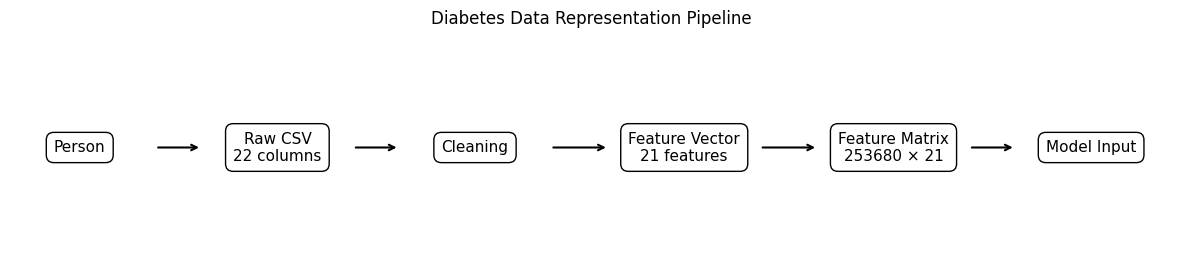

In [13]:
fig, ax = plt.subplots(
    figsize=(15, 3)
)

ax.axis("off")

steps = [
    ("Person", 0.06),
    ("Raw CSV\n22 columns", 0.23),
    ("Cleaning", 0.40),
    ("Feature Vector\n21 features", 0.58),
    (f"Feature Matrix\n{N} × {d}", 0.76),
    ("Model Input", 0.93)
]

for text, x_pos in steps:

    ax.text(
        x_pos,
        0.5,
        text,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="white",
            edgecolor="black"
        )
    )

for i in range(len(steps) - 1):

    ax.annotate(
        "",
        xy=(
            steps[i + 1][1] - 0.065,
            0.5
        ),
        xytext=(
            steps[i][1] + 0.065,
            0.5
        ),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.5
        )
    )

plt.title(
    "Diabetes Data Representation Pipeline"
)

plt.show()

## 9. Phân tích khám phá dữ liệu

Các biểu đồ sau khảo sát phân bố nhãn, phân bố đặc trưng, mối quan hệ sức khỏe và tương quan. Phần diễn giải chi tiết các biểu đồ được trình bày trong báo cáo cuối kỳ.

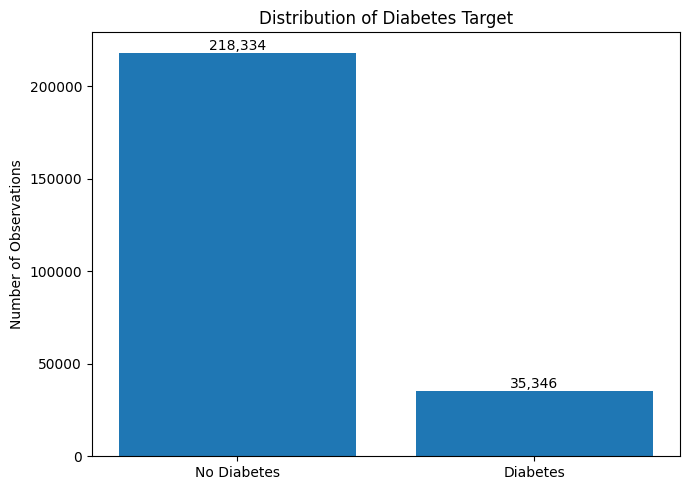

In [14]:
target_counts = (
    df_clean[TARGET]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["No Diabetes", "Diabetes"],
    target_counts.values
)

for bar, count in zip(
    bars,
    target_counts.values
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.title(
    "Distribution of Diabetes Target"
)

plt.ylabel(
    "Number of Observations"
)

plt.tight_layout()
plt.show()

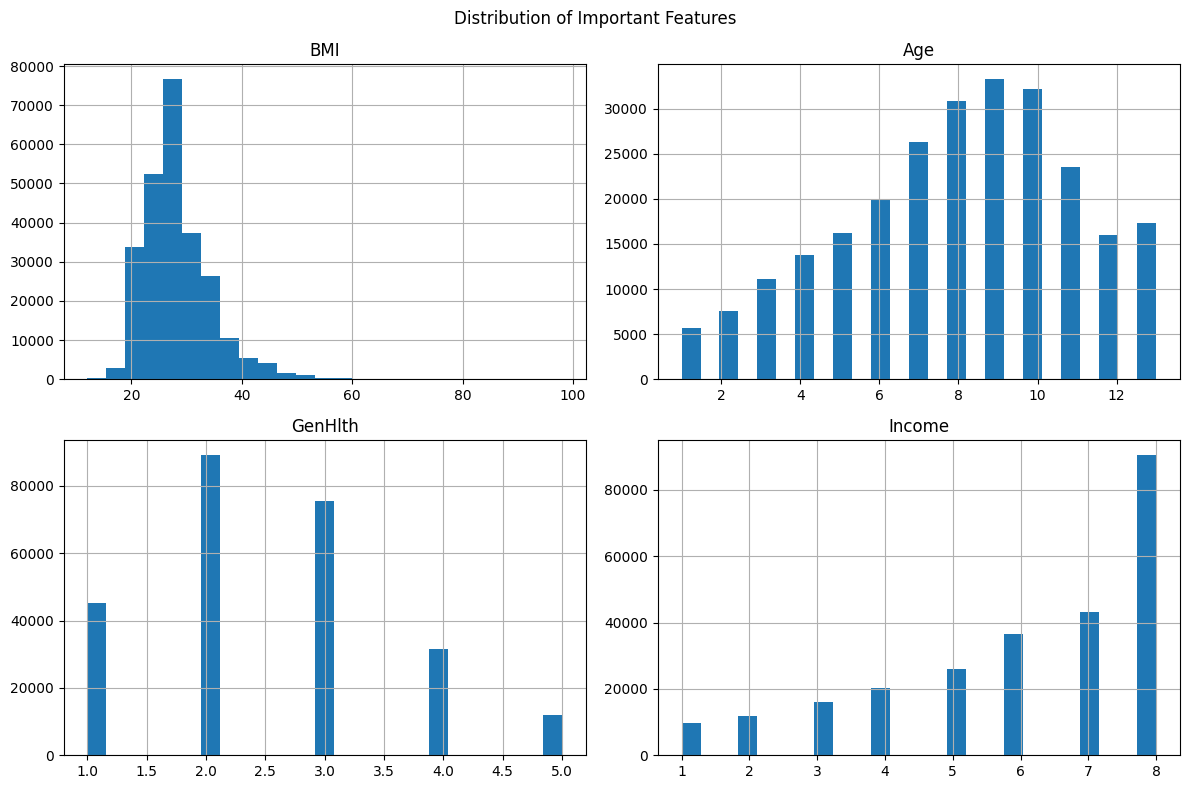

In [15]:
features_to_plot = [
    "BMI",
    "Age",
    "GenHlth",
    "Income"
]

df_clean[
    features_to_plot
].hist(
    figsize=(12, 8),
    bins=25
)

plt.suptitle(
    "Distribution of Important Features"
)

plt.tight_layout()
plt.show()

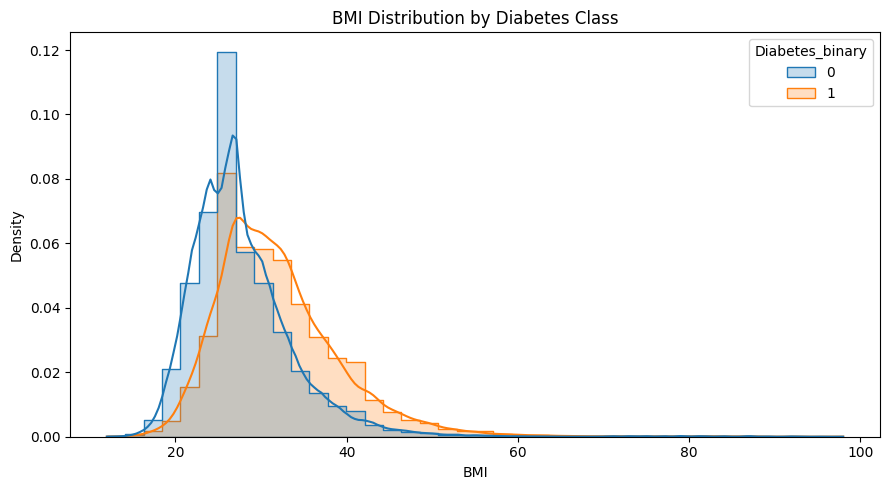

,count,mean,median,std
Diabetes_binary,,,,
0,218334,27.809999,27.0,6.29
1,35346,31.940001,31.0,7.36


In [16]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_clean,
    x="BMI",
    hue=TARGET,
    bins=40,
    stat="density",
    common_norm=False,
    kde=True,
    element="step"
)

plt.title(
    "BMI Distribution by Diabetes Class"
)

plt.tight_layout()
plt.show()


display(
    df_clean
    .groupby(TARGET)["BMI"]
    .agg([
        "count",
        "mean",
        "median",
        "std"
    ])
    .round(2)
)

,Diabetes_Rate_Percent
GenHlth,
1,2.52
2,7.16
3,17.79
4,31.01
5,37.89


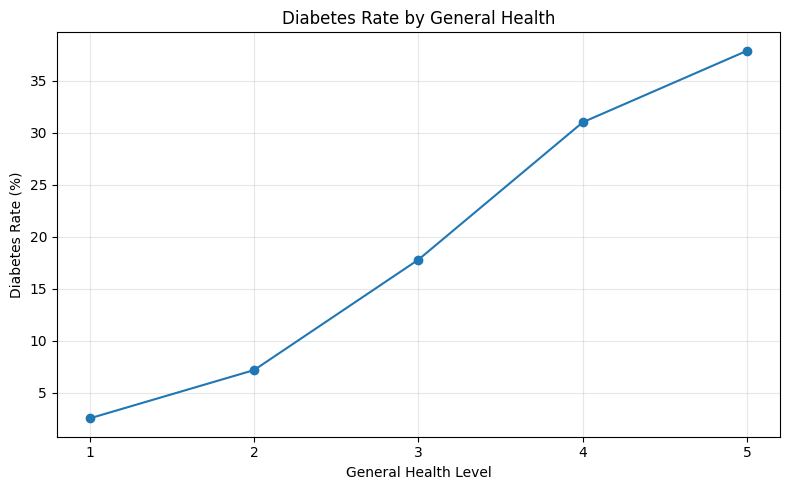

In [17]:
genhlth_rate = (
    df_clean
    .groupby("GenHlth")[TARGET]
    .mean()
    * 100
)

display(
    genhlth_rate
    .to_frame(
        "Diabetes_Rate_Percent"
    )
    .round(2)
)


plt.figure(figsize=(8, 5))

plt.plot(
    genhlth_rate.index,
    genhlth_rate.values,
    marker="o"
)

plt.xlabel(
    "General Health Level"
)

plt.ylabel(
    "Diabetes Rate (%)"
)

plt.title(
    "Diabetes Rate by General Health"
)

plt.xticks(
    genhlth_rate.index
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

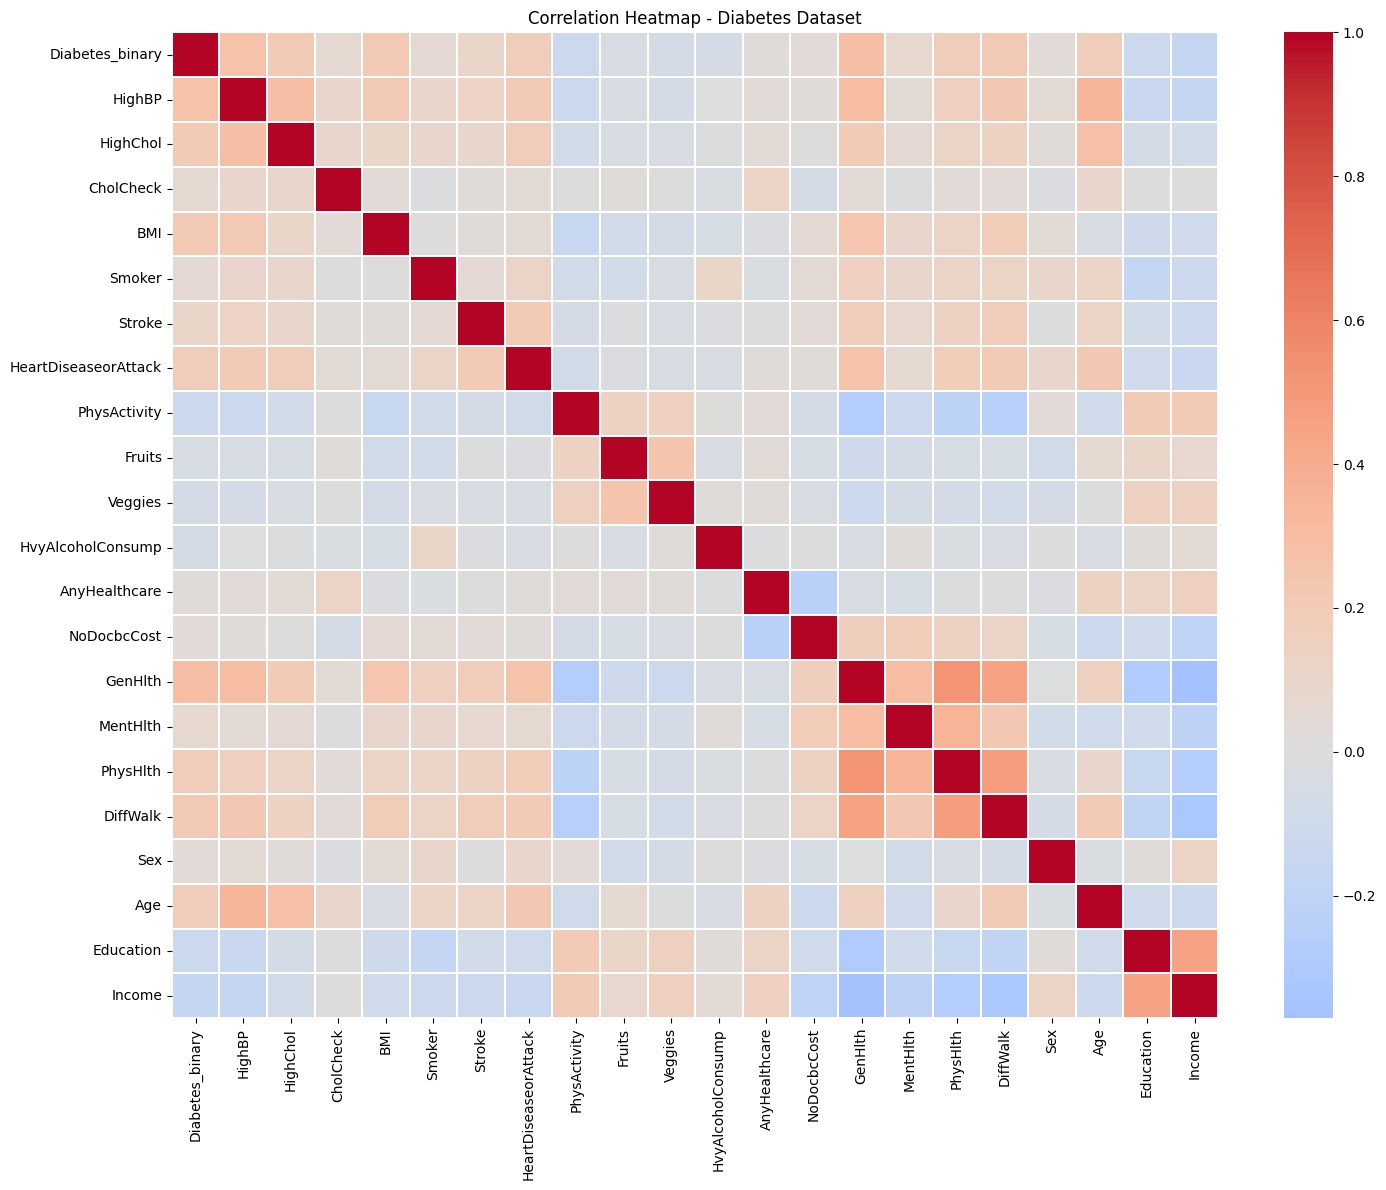

,Correlation_with_Diabetes
GenHlth,0.294
HighBP,0.263
DiffWalk,0.218
BMI,0.217
HighChol,0.200
Age,0.177
HeartDiseaseorAttack,0.177
PhysHlth,0.171
Stroke,0.106
MentHlth,0.069


In [18]:
corr = (
    df_clean
    .corr(numeric_only=True)
)

plt.figure(
    figsize=(15, 12)
)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title(
    "Correlation Heatmap - Diabetes Dataset"
)

plt.tight_layout()
plt.show()


target_corr = (
    corr[TARGET]
    .drop(TARGET)
    .sort_values(
        ascending=False
    )
)

display(
    target_corr
    .to_frame(
        "Correlation_with_Diabetes"
    )
    .round(3)
)

## 10. Chia tập train, validation và test

Dữ liệu được chia độc lập theo tỷ lệ 70% train, 15% validation và 15% test, đồng thời giữ nguyên tỷ lệ nhãn bằng stratify. Tập test không được dùng để fit tiền xử lý hoặc chọn mô hình.

In [19]:
X_train, X_temp, y_train, y_temp = (
    train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=y
    )
)

X_val, X_test, y_val, y_test = (
    train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=RANDOM_STATE,
        stratify=y_temp
    )
)

split_table = pd.DataFrame({
    "Set": [
        "Train",
        "Validation",
        "Test"
    ],

    "Rows": [
        len(X_train),
        len(X_val),
        len(X_test)
    ],

    "Percent": [
        len(X_train) / len(X) * 100,
        len(X_val) / len(X) * 100,
        len(X_test) / len(X) * 100
    ],

    "Diabetes_Percent": [
        y_train.mean() * 100,
        y_val.mean() * 100,
        y_test.mean() * 100
    ]
})

display(
    split_table.round(2)
)

,Set,Rows,Percent,Diabetes_Percent
0,Train,177576,70.0,13.93
1,Validation,38052,15.0,13.93
2,Test,38052,15.0,13.93


## 11. Mô hình cơ sở

Mô hình dự đoán lớp chiếm đa số được dùng làm mốc tối thiểu. Accuracy cao nhưng Recall của lớp tiểu đường bằng 0 cho thấy không thể chỉ dựa vào Accuracy.

In [20]:
baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(
    X_train,
    y_train
)

baseline_pred = baseline.predict(
    X_val
)

baseline_result = pd.DataFrame([{
    "Model": "Dummy Baseline",

    "Accuracy":
        accuracy_score(
            y_val,
            baseline_pred
        ),

    "Precision":
        precision_score(
            y_val,
            baseline_pred,
            zero_division=0
        ),

    "Recall":
        recall_score(
            y_val,
            baseline_pred,
            zero_division=0
        ),

    "F1":
        f1_score(
            y_val,
            baseline_pred,
            zero_division=0
        )
}])

display(
    baseline_result.round(4)
)

,Model,Accuracy,Precision,Recall,F1
0,Dummy Baseline,0.8607,0.0,0.0,0.0


## 12. Xây dựng mô hình

Năm mô hình phân loại cổ điển được huấn luyện theo cùng một quy trình train/validation. Chuẩn hóa dữ liệu được đặt trong pipeline để tránh rò rỉ dữ liệu.

In [21]:
models = {

    "Logistic Regression": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]),

    "KNN": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            KNeighborsClassifier(
                n_neighbors=9,
                n_jobs=-1
            )
        )
    ]),

    "Decision Tree": Pipeline([
        (
            "model",
            DecisionTreeClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]),

    "Random Forest": Pipeline([
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]),

    "Linear SVM": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LinearSVC(
                class_weight="balanced",
                dual=False,
                max_iter=10000,
                random_state=RANDOM_STATE
            )
        )
    ])
}

print(
    "Number of models:",
    len(models)
)

Number of models: 5


In [22]:
def get_score_values(
    model,
    X_data
):

    if hasattr(
        model,
        "predict_proba"
    ):

        return (
            model
            .predict_proba(
                X_data
            )[:, 1]
        )

    if hasattr(
        model,
        "decision_function"
    ):

        return (
            model
            .decision_function(
                X_data
            )
        )

    return None

In [23]:
results = []

trained_models = {}

for name, model in models.items():

    print(
        f"Training {name}..."
    )

    start = time.time()

    model.fit(
        X_train,
        y_train
    )

    training_time = (
        time.time()
        - start
    )

    trained_models[name] = model

    pred = model.predict(
        X_val
    )

    score_values = (
        get_score_values(
            model,
            X_val
        )
    )

    results.append({

        "Model":
            name,

        "Accuracy":
            accuracy_score(
                y_val,
                pred
            ),

        "Precision":
            precision_score(
                y_val,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_val,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_val,
                pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_val,
                score_values
            ),

        "Training_Time_s":
            training_time
    })

    print(
        f"Done: {training_time:.2f}s\n"
    )


results_df = pd.DataFrame(
    results
)

results_df = (
    results_df
    .sort_values(
        by=[
            "F1",
            "Recall"
        ],
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    results_df.round(4)
)

Training Logistic Regression...
Done: 0.29s

Training KNN...
Done: 0.08s

Training Decision Tree...
Done: 1.19s

Training Random Forest...
Done: 6.19s

Training Linear SVM...
Done: 0.51s



,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time_s
0,Logistic Regression,0.7302,0.3096,0.7610,0.4401,0.8215,0.2851
1,Linear SVM,0.7254,0.3063,0.7676,0.4379,0.8211,0.5076
2,Decision Tree,0.7972,0.2865,0.3057,0.2958,0.5919,1.1944
3,KNN,0.8546,0.4424,0.1667,0.2422,0.7573,0.0769
4,Random Forest,0.8570,0.4605,0.1530,0.2296,0.7970,6.1905


## 13. Biểu diễn số cuối cùng

Phần này hiển thị một vector đặc trưng trước và sau chuẩn hóa, đồng thời cho biết kích thước đầy đủ của ma trận train được đưa vào các mô hình tuyến tính.

In [24]:
lr_pipeline = (
    trained_models[
        "Logistic Regression"
    ]
)

fitted_scaler = (
    lr_pipeline
    .named_steps["scaler"]
)


raw_sample = (
    X_train.iloc[[0]]
)

scaled_sample = (
    fitted_scaler
    .transform(
        raw_sample
    )
)


print(
    "===== BEFORE SCALING ====="
)

display(raw_sample)

print(
    "Raw vector:"
)

print(
    raw_sample
    .to_numpy()[0]
)


print(
    "\n===== AFTER SCALING ====="
)

print(
    scaled_sample[0]
)


print(
    "\nRaw shape   :",
    raw_sample.shape
)

print(
    "Scaled shape:",
    scaled_sample.shape
)


X_train_scaled = (
    fitted_scaler
    .transform(
        X_train
    )
)


print(
    "\nScaled training matrix shape:",
    X_train_scaled.shape
)


scaling_summary = pd.DataFrame({
    "Feature":
        X.columns,

    "Mean_After_Scaling":
        X_train_scaled.mean(
            axis=0
        ),

    "Std_After_Scaling":
        X_train_scaled.std(
            axis=0
        )
})

display(
    scaling_summary.round(4)
)

===== BEFORE SCALING =====


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
231121,0.0,1.0,1.0,22.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,12.0,6.0,6.0


Raw vector:
[ 0.  1.  1. 22.  1.  0.  0.  1.  1.  1.  0.  1.  0.  2.  0.  0.  0.  0.
 12.  6.  6.]

===== AFTER SCALING =====
[-0.86692184  1.164861    0.1977071  -0.9649567   1.1209668  -0.20493045
 -0.32292458  0.5663209   0.75853324  0.4818178  -0.24224481  0.22728907
 -0.30393875 -0.47881615 -0.4299377  -0.48668107 -0.44917053 -0.88946384
  1.3009406   0.96354187 -0.02582259]

Raw shape   : (1, 21)
Scaled shape: (1, 21)

Scaled training matrix shape: (177576, 21)


,Feature,Mean_After_Scaling,Std_After_Scaling
0,HighBP,-0.0,1.0
1,HighChol,-0.0,1.0
2,CholCheck,-0.0,1.0
3,BMI,0.0,1.0
4,Smoker,-0.0,1.0
5,Stroke,-0.0,1.0
6,HeartDiseaseorAttack,-0.0,1.0
7,PhysActivity,0.0,1.0
8,Fruits,0.0,1.0
9,Veggies,-0.0,1.0


## 14. So sánh trên tập validation

Các mô hình được so sánh bằng Accuracy, Precision, Recall, F1-score, ROC-AUC và thời gian huấn luyện. F1 và Recall được ưu tiên vì lớp tiểu đường ít hơn đáng kể.

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Logistic Regression,0.7302,0.3096,0.7610,0.4401,0.8215
Linear SVM,0.7254,0.3063,0.7676,0.4379,0.8211
Decision Tree,0.7972,0.2865,0.3057,0.2958,0.5919
KNN,0.8546,0.4424,0.1667,0.2422,0.7573
Random Forest,0.8570,0.4605,0.1530,0.2296,0.7970


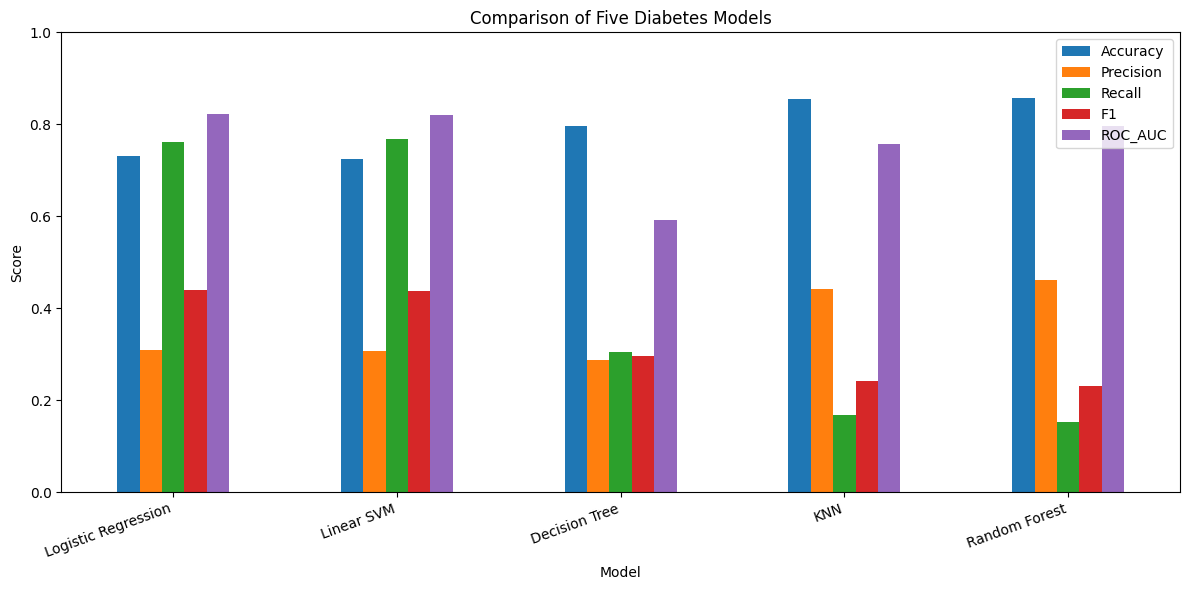

In [25]:
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

comparison = (
    results_df
    .set_index("Model")
    [metric_columns]
)

display(
    comparison.round(4)
)


comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Comparison of Five Diabetes Models"
)

plt.ylabel(
    "Score"
)

plt.xlabel(
    "Model"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

## 15. Chọn mô hình cuối cùng

Mô hình cuối chỉ được chọn dựa trên kết quả validation. Ma trận nhầm lẫn và báo cáo phân loại cho thấy sự đánh đổi giữa phát hiện ca tiểu đường và số trường hợp dương tính giả.

Selected model: Logistic Regression
              precision    recall  f1-score   support

 No Diabetes       0.95      0.73      0.82     32750
    Diabetes       0.31      0.76      0.44      5302

    accuracy                           0.73     38052
   macro avg       0.63      0.74      0.63     38052
weighted avg       0.86      0.73      0.77     38052



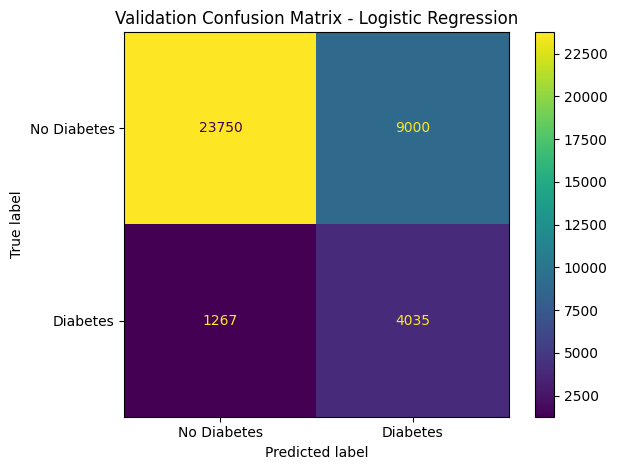

In [26]:
best_name = (
    results_df
    .iloc[0]["Model"]
)

best_model = (
    trained_models[
        best_name
    ]
)

print(
    "Selected model:",
    best_name
)


val_pred = (
    best_model
    .predict(
        X_val
    )
)


print(
    classification_report(
        y_val,
        val_pred,
        target_names=[
            "No Diabetes",
            "Diabetes"
        ],
        zero_division=0
    )
)


ConfusionMatrixDisplay.from_predictions(
    y_val,
    val_pred,
    display_labels=[
        "No Diabetes",
        "Diabetes"
    ]
)

plt.title(
    f"Validation Confusion Matrix - {best_name}"
)

plt.tight_layout()
plt.show()

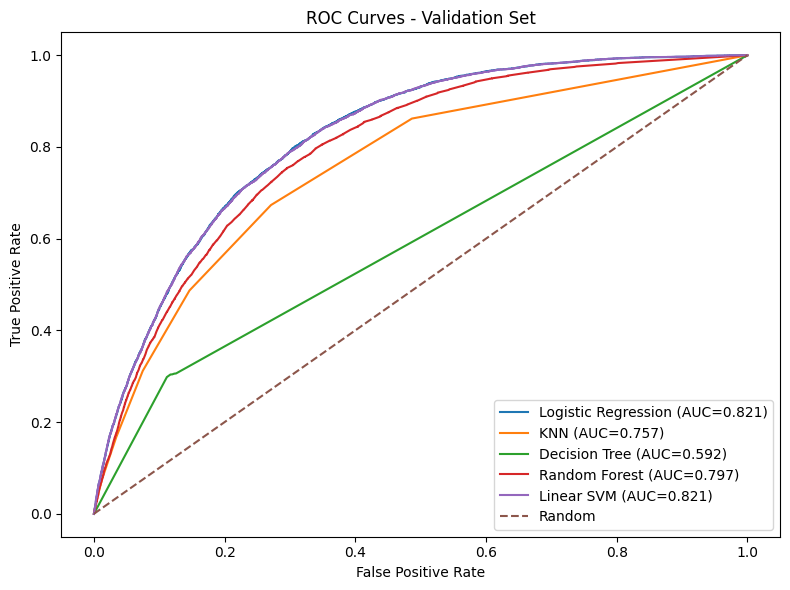

In [27]:
plt.figure(
    figsize=(8, 6)
)

for name, model in trained_models.items():

    score_values = (
        get_score_values(
            model,
            X_val
        )
    )

    fpr, tpr, _ = (
        roc_curve(
            y_val,
            score_values
        )
    )

    auc_value = (
        roc_auc_score(
            y_val,
            score_values
        )
    )

    plt.plot(
        fpr,
        tpr,
        label=(
            f"{name} "
            f"(AUC={auc_value:.3f})"
        )
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curves - Validation Set"
)

plt.legend()

plt.tight_layout()
plt.show()

## 16. Huấn luyện lại và đánh giá trên tập test

Mô hình được chọn được huấn luyện lại bằng train cộng validation, sau đó chỉ đánh giá một lần trên tập test chưa từng được sử dụng.

===== FINAL TEST RESULT =====


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.7339,0.3135,0.7648,0.4447,0.8215


              precision    recall  f1-score   support

 No Diabetes       0.95      0.73      0.82     32750
    Diabetes       0.31      0.76      0.44      5302

    accuracy                           0.73     38052
   macro avg       0.63      0.75      0.63     38052
weighted avg       0.86      0.73      0.77     38052



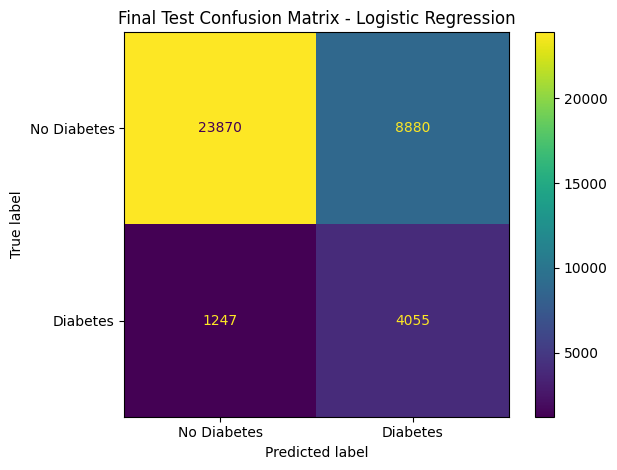

In [28]:
X_train_final = pd.concat(
    [
        X_train,
        X_val
    ],
    axis=0
)

y_train_final = pd.concat(
    [
        y_train,
        y_val
    ],
    axis=0
)


final_model = clone(
    models[
        best_name
    ]
)


final_model.fit(
    X_train_final,
    y_train_final
)


test_pred = (
    final_model
    .predict(
        X_test
    )
)


test_score_values = (
    get_score_values(
        final_model,
        X_test
    )
)


test_results = pd.DataFrame([{

    "Model":
        best_name,

    "Accuracy":
        accuracy_score(
            y_test,
            test_pred
        ),

    "Precision":
        precision_score(
            y_test,
            test_pred,
            zero_division=0
        ),

    "Recall":
        recall_score(
            y_test,
            test_pred,
            zero_division=0
        ),

    "F1":
        f1_score(
            y_test,
            test_pred,
            zero_division=0
        ),

    "ROC_AUC":
        roc_auc_score(
            y_test,
            test_score_values
        )

}])


print(
    "===== FINAL TEST RESULT ====="
)

display(
    test_results.round(4)
)


print(
    classification_report(
        y_test,
        test_pred,
        target_names=[
            "No Diabetes",
            "Diabetes"
        ],
        zero_division=0
    )
)


ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    display_labels=[
        "No Diabetes",
        "Diabetes"
    ]
)

plt.title(
    f"Final Test Confusion Matrix - {best_name}"
)

plt.tight_layout()
plt.show()

## 17. Phân tích lỗi

False Negative đặc biệt quan trọng trong bài toán sàng lọc vì đó là các trường hợp mắc tiểu đường nhưng mô hình không phát hiện được.

In [29]:
tn, fp, fn, tp = (
    confusion_matrix(
        y_test,
        test_pred
    )
    .ravel()
)


error_analysis = pd.DataFrame({
    "Metric": [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive",
        "False Positive Rate",
        "False Negative Rate"
    ],

    "Value": [
        tn,
        fp,
        fn,
        tp,
        fp / (fp + tn),
        fn / (fn + tp)
    ]
})

display(
    error_analysis.round(4)
)

,Metric,Value
0,True Negative,23870.0000
1,False Positive,8880.0000
2,False Negative,1247.0000
3,True Positive,4055.0000
4,False Positive Rate,0.2711
5,False Negative Rate,0.2352


## 18. Lưu mô hình

Tiền xử lý và bộ phân loại đã fit được lưu chung trong một pipeline để quá trình dự đoán sử dụng đúng các phép biến đổi khi huấn luyện.

In [30]:
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_PATH = (
    MODEL_DIR
    /
    "diabetes_pipeline.joblib"
)


artifact = {

    "pipeline":
        final_model,

    "model_name":
        best_name,

    "feature_names":
        X.columns.tolist(),

    "target":
        TARGET,

    "N":
        N,

    "d":
        d,

    "random_state":
        RANDOM_STATE,

    "test_metrics":
        test_results
        .iloc[0]
        .to_dict()
}


joblib.dump(
    artifact,
    MODEL_PATH
)


print(
    "Saved model:",
    MODEL_PATH
)

Saved model: D:\Assignment2\models\diabetes_pipeline.joblib


## 19. Dự đoán cho bệnh nhân mới

Artifact đã lưu được tải lại và áp dụng cho một bệnh nhân mới có đúng tên và thứ tự đặc trưng mà mô hình yêu cầu.

In [31]:
loaded_artifact = (
    joblib.load(
        MODEL_PATH
    )
)

loaded_model = (
    loaded_artifact[
        "pipeline"
    ]
)

feature_names = (
    loaded_artifact[
        "feature_names"
    ]
)


new_patient = pd.DataFrame([{

    "HighBP": 1,
    "HighChol": 1,
    "CholCheck": 1,

    "BMI": 31,

    "Smoker": 1,
    "Stroke": 0,
    "HeartDiseaseorAttack": 0,

    "PhysActivity": 1,
    "Fruits": 1,
    "Veggies": 1,

    "HvyAlcoholConsump": 0,
    "AnyHealthcare": 1,
    "NoDocbcCost": 0,

    "GenHlth": 3,
    "MentHlth": 5,
    "PhysHlth": 10,

    "DiffWalk": 0,
    "Sex": 1,

    "Age": 9,
    "Education": 5,
    "Income": 6

}])


new_patient = (
    new_patient[
        feature_names
    ]
)


print(
    "===== NEW USER INPUT ====="
)

display(
    new_patient
)


prediction = int(
    loaded_model
    .predict(
        new_patient
    )[0]
)


print(
    "Loaded model:",
    loaded_artifact[
        "model_name"
    ]
)

print(
    "Predicted class:",
    prediction
)


if hasattr(
    loaded_model,
    "predict_proba"
):

    probability_estimate = (
        loaded_model
        .predict_proba(
            new_patient
        )[0, 1]
    )

    print(
        "Model probability estimate:",
        round(
            probability_estimate,
            4
        )
    )

elif hasattr(
    loaded_model,
    "decision_function"
):

    decision_score = (
        loaded_model
        .decision_function(
            new_patient
        )[0]
    )

    print(
        "Model decision score:",
        round(
            float(decision_score),
            4
        )
    )

===== NEW USER INPUT =====


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1,1,1,31,1,0,0,1,1,1,0,1,0,3,5,10,0,1,9,5,6


Loaded model: Logistic Regression
Predicted class: 1
Model probability estimate: 0.6979
